<a href="https://colab.research.google.com/github/jose-luis-hernandez-amaya/Simulaci-n-1/blob/main/Flecha_y_cojinete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

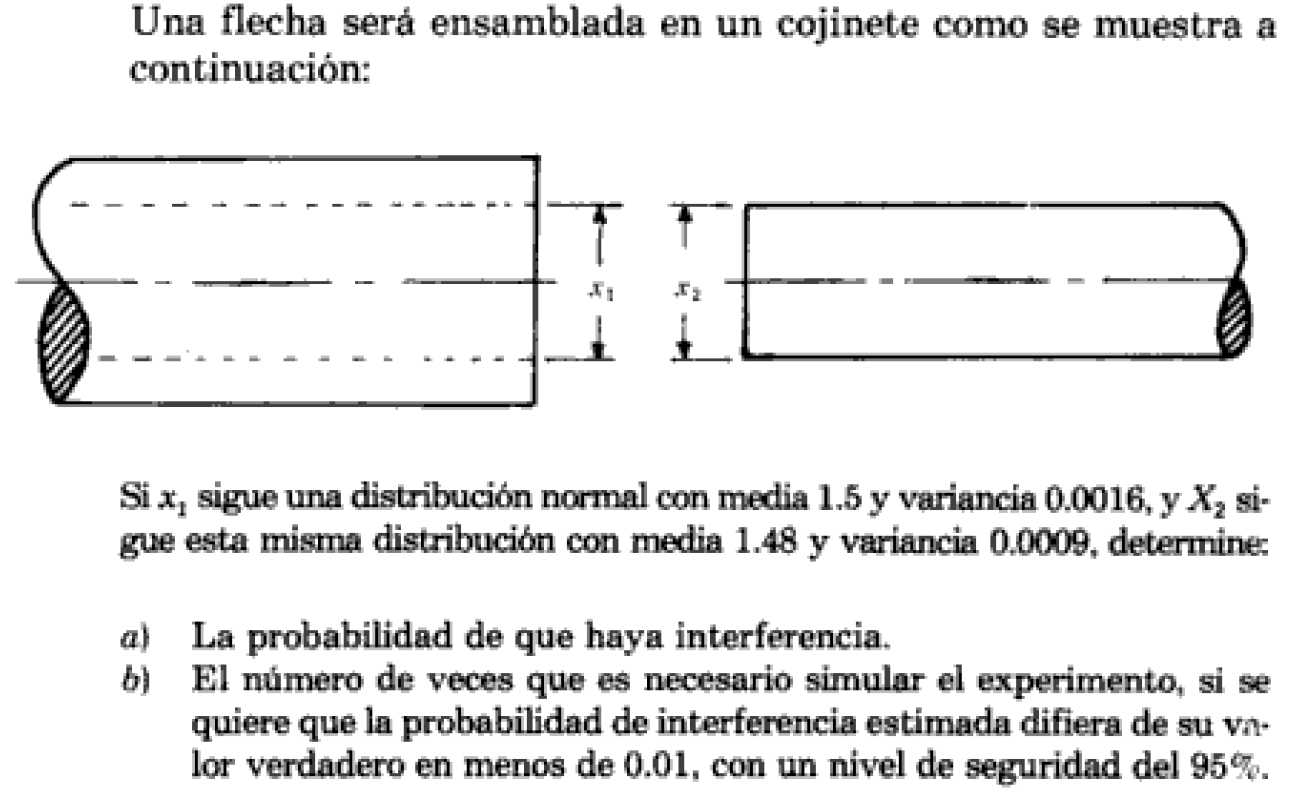

# Solución Analíticamente

$Datos$
*   Cojinete: $x_1 \sim N(\mu_1 = 1.5, \sigma_1^2 = 0.0016)$
*   Flecha: $x_2 \sim N(\mu_2 = 1.48, \sigma_2^2 = 0.0009)$







# a)

Llamemos $Y$ a la holgura: $$Y=x_1-x_2$$

Como $x_1$ y $x_2$ son variables normales independientes, su diferencia también sigue una distribución normal

*   Media de Y: La media de una diferencia es la diferencia de las medias.
$$\mu_Y = \mu_1 - \mu_2 = 0.02$$
*   Varianza de Y: La varianza de una suma o diferencia de variables independientes es siempre la suma de sus varianzas
$$\sigma_Y^2 = \sigma_1^2 + \sigma_2^2 = 0.0025$$
*   Desviación estandar:
$$\sigma_Y = \sqrt{0.0025} = 0.05$$

Queremos la probabilidad de interferencia, que es. Para resolver esto, estandarizamos a la variable $Z$:$$Z = \frac{Y - \mu_Y}{\sigma_Y} = -0.4$$

Con las tablas de distribución normal, encontramos que:
$$P(Z < -0.4) \approx 0.3446$$

La probabilidad analítica de que haya interferencia es de aproximadamente 34.46%

# b)

Los datos que nos da el inciso son:


*   Margen de error ($E$) es de 0.01
*   Nivel de seguridad: 95%. Esto corresponde a un valor crítico en la distribución normal de $Z_{\alpha/2} = 1.96$.
*   Probabilidad: $p=0.3446$ que acabamos de calcular

La fórmula estadística para calcular el tamaño de muestra $n$ al estimar proporciones es:$$n = \frac{Z^2 \cdot p(1 - p)}{E^2}$$
$$n = \frac{(1.96)^2 \cdot (0.3446)(1 - 0.3446)}{(0.01)^2} = 8676.2$$ \
Es necesario simular el experimento 8677 veces para alcanzar ese nivel de precisión y confianza.


# Simulacion

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy.stats as st

def simular_piezas():
    # np.random.normal recibe (media, desviacion_estandar)
    x1_cojinete = np.random.normal(1.5, 0.04)
    x2_flecha = np.random.normal(1.48, 0.03)
    return x1_cojinete, x2_flecha

In [7]:
def hay_interferencia():
    x1, x2 = simular_piezas()
    if x2 > x1:
        return 1
    else:
        return 0

In [8]:
def experimento_ensamblaje(iteraciones):
    i = 1
    piezas_atoradas = 0
    lista_probabilidades = []

    while i <= iteraciones:
        piezas_atoradas += hay_interferencia()
        prob_actual = piezas_atoradas / i
        lista_probabilidades.append(prob_actual)
        i += 1

    return lista_probabilidades

In [9]:
# Corremos 1 experimento con el número exacto que calculamos en el inciso B
iteraciones_requeridas = 8677
exp = experimento_ensamblaje(iteraciones_requeridas)

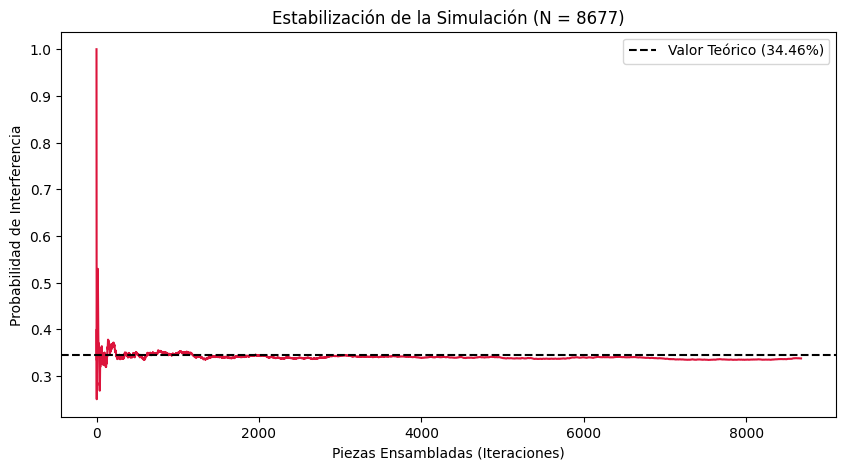

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(exp, color='crimson')
plt.axhline(y=0.3446, color='black', linestyle='--', label='Valor Teórico (34.46%)')
plt.xlabel('Piezas Ensambladas (Iteraciones)')
plt.ylabel('Probabilidad de Interferencia')
plt.title(f'Estabilización de la Simulación (N = {iteraciones_requeridas})')
plt.legend()
plt.show()

In [11]:
def simulacion_replicas_ensamble(repeticiones, n_muestral):
    lista_medias = []
    for _ in range(repeticiones):
        promedio_final = experimento_ensamblaje(n_muestral)[-1]
        lista_medias.append(promedio_final)
    return lista_medias

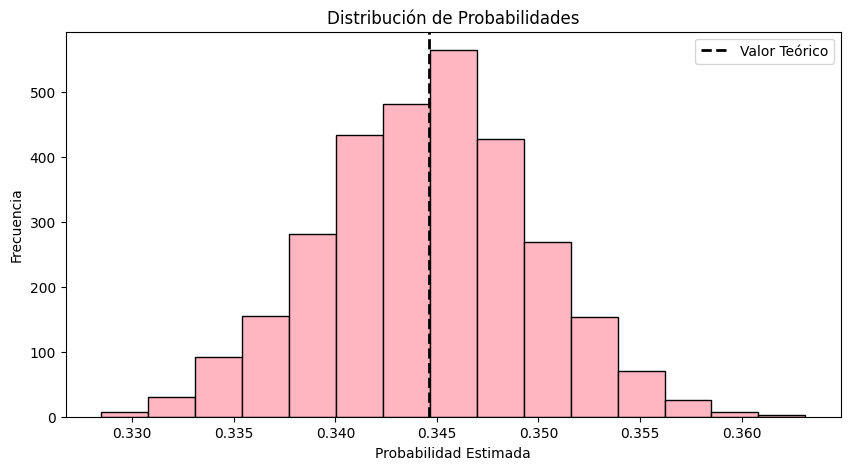

In [16]:
simulacion = simulacion_replicas_ensamble(3000, iteraciones_requeridas)

plt.figure(figsize=(10, 5))
plt.hist(simulacion, bins=15, color='lightpink', edgecolor='black')
plt.axvline(x=0.3446, color='black', linestyle='--', linewidth=2, label='Valor Teórico')
plt.xlabel('Probabilidad Estimada')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades')
plt.legend()
plt.show()

In [17]:
mean_simulacion = np.mean(simulacion)
std_simulacion = np.std(simulacion)
n = len(simulacion)
standard_error = std_simulacion / np.sqrt(n)

confidence_interval = st.norm.interval(confidence=0.95, loc=mean_simulacion, scale=standard_error)

print(f"Probabilidad promedio simulada: {mean_simulacion:.4f}")
print(f"Desviación estándar de las simulaciones: {std_simulacion:.4f}")
print(f"Intervalo de confianza del 95%: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")

Probabilidad promedio simulada: 0.3446
Desviación estándar de las simulaciones: 0.0051
Intervalo de confianza del 95%: (0.3444, 0.3448)
